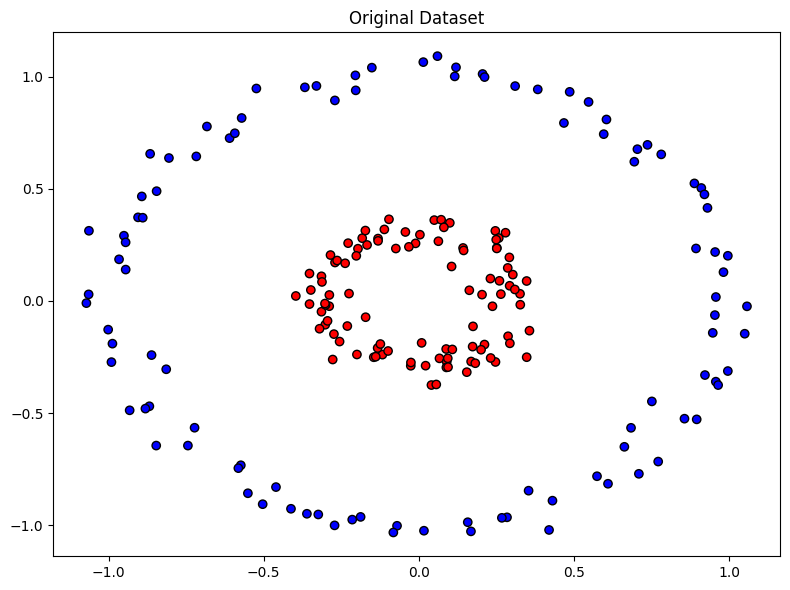

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

X, Y = make_circles(n_samples=200, factor=0.3, noise=0.05, random_state=42)

plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1], c=Y, cmap='bwr', edgecolor='k')
plt.title('Original Dataset')
plt.tight_layout()
plt.show()

In [2]:
kernels = {
    'Linear':SVC(kernel='linear'),
    'Polynomial':SVC(kernel='poly', degree=3),
    'RBF':SVC(kernel='rbf', gamma=1.5)
}

for kernel, model in kernels.items():
    model.fit(X, Y)
    y_pred = model.predict(X)
    acc = accuracy_score(Y, y_pred)
    print(f'{kernel} Kernel Accuracy: {acc * 100}')

Linear Kernel Accuracy: 69.0
Polynomial Kernel Accuracy: 71.0
RBF Kernel Accuracy: 100.0


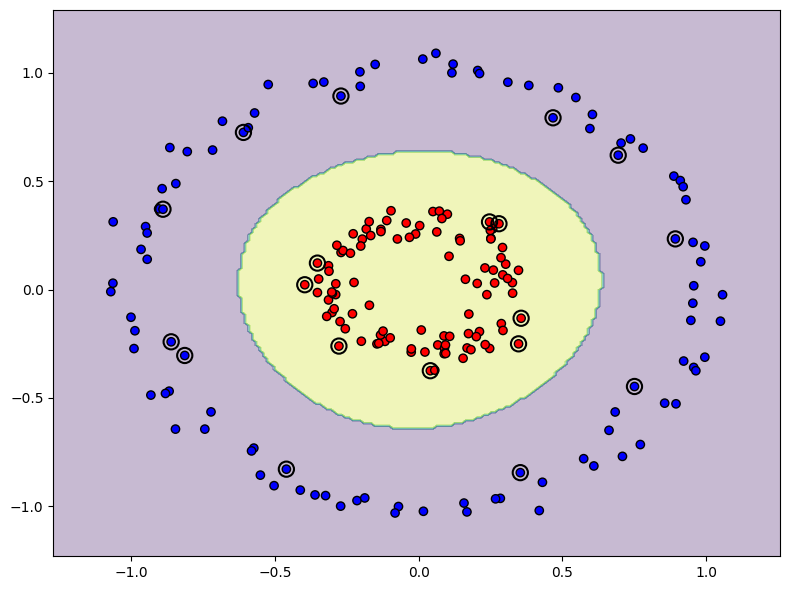

In [7]:
rbf_kernel = kernels['RBF']

xx, yy = np.meshgrid(
    np.linspace(X[:,0].min()-0.2, X[:,0].max()+0.2, 200),
    np.linspace(X[:,1].min()-0.2, X[:,1].max()+0.2, 200)
)

grid = np.c_[xx.ravel(), yy.ravel()]
Z = rbf_kernel.predict(grid).reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:,0], X[:,1], c=Y, cmap='bwr', edgecolor='k')
plt.scatter(
    rbf_kernel.support_vectors_[:,0],
    rbf_kernel.support_vectors_[:,1],
    facecolor='none',
    color='white',
    s=120,
    edgecolors='black',
    linewidth=1.5,
    label='Support Vectors'
)
plt.tight_layout()

In [4]:
rbf_kernel.support_vectors_

array([[-0.27065215,  0.89356689],
       [-0.86158216, -0.24116642],
       [ 0.35377722, -0.84529069],
       [-0.46052936, -0.8292799 ],
       [-0.81433541, -0.30432872],
       [ 0.89342825,  0.23397857],
       [-0.61001019,  0.72556038],
       [-0.89005318,  0.370912  ],
       [ 0.69455383,  0.62042534],
       [ 0.46768442,  0.79307202],
       [ 0.7511687 , -0.44752156],
       [ 0.24659584,  0.31232139],
       [ 0.35657593, -0.13241326],
       [-0.35249426,  0.12218743],
       [-0.39653997,  0.02228722],
       [-0.27764463, -0.26089743],
       [ 0.04056321, -0.37464235],
       [ 0.34763749, -0.25057114],
       [ 0.27946451,  0.30402501]])